## Task 1: Dataset Design

In [1]:
import numpy as np
import pandas as pd
import random

# Define the group number
G = 10 # Let's assume group number is 10 for demonstration

# Set random seeds for reproducibility
random.seed(G)
np.random.seed(G)

# 1.1 Number of Medicines
K = (G % 3) + 5
print(f"Group Number (G): {G}")
print(f"Total Number of Medicines (K): {K}")

# 1.2 Hidden Success Probability
Pi = [0.4 + ((G + i) % 6) * 0.07 for i in range(K)]
print("Hidden Success Probabilities (Pi) for each medicine:")
for i, prob in enumerate(Pi):
    print(f"Medicine {i}: {prob:.3f}")

Group Number (G): 10
Total Number of Medicines (K): 6
Hidden Success Probabilities (Pi) for each medicine:
Medicine 0: 0.680
Medicine 1: 0.750
Medicine 2: 0.400
Medicine 3: 0.470
Medicine 4: 0.540
Medicine 5: 0.610


In [2]:
# 1.3 Patient Severity and Utility Logic
# Generate 1000 patient records
patient_ids = np.arange(1000)
severity_scores = (patient_ids % 5) + 1

# Create the initial dataset structure
dataset = pd.DataFrame({
    'patient_id': patient_ids,
    'severity_score': severity_scores,
    'assigned_medicine': -1, # To be filled dynamically
    'clinical_outcome': -1,  # To be filled dynamically
    'utility_score': -1.0    # To be filled dynamically
})

# Display the first 10 dataset rows as required by Task 1.3
print("\nFirst 10 rows of the initial dataset:")
display(dataset.head(10))


First 10 rows of the initial dataset:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,-1,-1,-1.0
1,1,2,-1,-1,-1.0
2,2,3,-1,-1,-1.0
3,3,4,-1,-1,-1.0
4,4,5,-1,-1,-1.0
5,5,1,-1,-1,-1.0
6,6,2,-1,-1,-1.0
7,7,3,-1,-1,-1.0
8,8,4,-1,-1,-1.0
9,9,5,-1,-1,-1.0


## Task 2: Immediate Exploitation Strategy

In [3]:
# Function to simulate a single patient's treatment and outcome
def simulate_patient_outcome(medicine_idx, severity, hidden_probabilities):
    # Clinical outcome
    # boost success probability to increase number of 1 outcomes (cap at 1.0)
    success_prob = min(1.0, hidden_probabilities[medicine_idx] + 0.0)
    clinical_outcome = 1 if random.random() < success_prob else 0

    # Utility score
    utility_score = clinical_outcome * (1-(severity / 10))

    return clinical_outcome, utility_score

# Immediate Exploitation Strategy Implementation
def immediate_exploitation_strategy(num_patients, K, Pi, dataset_df):
    # Initialize statistics for each medicine
    medicine_rewards = [0.0] * K  # Stores running average reward
    medicine_counts = [0] * K
    cumulative_reward = 0

    # Make a copy of the dataset to store results for this strategy
    strategy_dataset = dataset_df.copy()

    # Hint: Test each medicine exactly 10 times initially
    initial_exploration_rounds = 10
    for med_idx in range(K):
        for _ in range(initial_exploration_rounds):
            if num_patients <= 0: # Ensure we don't exceed num_patients
                break

            patient_idx = len(dataset_df) - num_patients # Get current patient_id from the original dataset
            severity = dataset_df.loc[patient_idx, 'severity_score']

            # Simulate outcome
            clinical_outcome, utility_score = simulate_patient_outcome(med_idx, severity, Pi)

            # Update statistics using incremental average: avg += (reward - avg) / n
            medicine_counts[med_idx] += 1
            medicine_rewards[med_idx] += (utility_score - medicine_rewards[med_idx]) / medicine_counts[med_idx]
            cumulative_reward += utility_score

            # Record results in the strategy-specific dataset
            strategy_dataset.loc[patient_idx, 'assigned_medicine'] = med_idx
            strategy_dataset.loc[patient_idx, 'clinical_outcome'] = clinical_outcome
            strategy_dataset.loc[patient_idx, 'utility_score'] = utility_score

            num_patients -= 1
        if num_patients <= 0:
            break

    # After initial exploration, exploit the best performing medicine
    for patient_idx_offset in range(len(dataset_df) - num_patients, len(dataset_df)):
        # Skip patients already treated in initial exploration
        if strategy_dataset.loc[patient_idx_offset, 'assigned_medicine'] != -1:
            continue

        # Determine the best medicine based on average reward (already stored as running average)
        avg_rewards = [medicine_rewards[i] if medicine_counts[i] > 0 else -1 for i in range(K)]
        best_medicine_idx = np.argmax(avg_rewards)

        severity = dataset_df.loc[patient_idx_offset, 'severity_score']

        # Simulate outcome
        clinical_outcome, utility_score = simulate_patient_outcome(best_medicine_idx, severity, Pi)

        # Update statistics using incremental average: avg += (reward - avg) / n
        medicine_counts[best_medicine_idx] += 1
        medicine_rewards[best_medicine_idx] += (utility_score - medicine_rewards[best_medicine_idx]) / medicine_counts[best_medicine_idx]
        cumulative_reward += utility_score

        # Record results
        strategy_dataset.loc[patient_idx_offset, 'assigned_medicine'] = best_medicine_idx
        strategy_dataset.loc[patient_idx_offset, 'clinical_outcome'] = clinical_outcome
        strategy_dataset.loc[patient_idx_offset, 'utility_score'] = utility_score

    return cumulative_reward, strategy_dataset

# Run the Immediate Exploitation Strategy
num_patients_total = 1000
cumulative_reward_ie, ie_dataset = immediate_exploitation_strategy(num_patients_total, K, Pi, dataset.copy())

print(f"Cumulative Reward for Immediate Exploitation Strategy: {cumulative_reward_ie:.2f}")
print("\nFirst 10 rows of the dataset after Immediate Exploitation:")
display(ie_dataset.head(100))
dataset.to_csv('dataset.csv', index=False)
ie_dataset.to_csv('ie_dataset.csv', index=False)


Cumulative Reward for Immediate Exploitation Strategy: 477.80

First 10 rows of the dataset after Immediate Exploitation:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,1,0.9
1,1,2,0,1,0.8
2,2,3,0,1,0.7
3,3,4,0,1,0.6
4,4,5,0,0,0.0
...,...,...,...,...,...
95,95,1,0,1,0.9
96,96,2,0,1,0.8
97,97,3,0,1,0.7
98,98,4,0,1,0.6


## Task 3: Controlled Clinical Trial Strategy

In [4]:

def controlled_clinical_trial_strategy(num_patients, K, Pi, dataset_df, exploration_rate):
    medicine_rewards = [0.0] * K  # Stores running average reward
    medicine_counts = [0] * K
    cumulative_reward = 0
    strategy_dataset = dataset_df.copy()

    for patient_idx in range(num_patients):
        assigned_medicine = -1

        if random.random() < exploration_rate: # Explore
            assigned_medicine = random.randrange(K)
        else: # Exploit
            # Choose the best medicine based on average reward (stored as running average)
            # Handle cases where a medicine hasn't been tested yet to avoid division by zero
            # Prioritize untested arms for exploitation in a controlled manne
            avg_rewards = [medicine_rewards[i] if medicine_counts[i] > 0 else 0 for i in range(K)]
            assigned_medicine = np.argmax(avg_rewards)

        severity = dataset_df.loc[patient_idx, 'severity_score']
        clinical_outcome, utility_score = simulate_patient_outcome(assigned_medicine, severity, Pi)

        # Update statistics using incremental average: avg += (reward - avg) / n
        medicine_counts[assigned_medicine] += 1
        medicine_rewards[assigned_medicine] += (utility_score - medicine_rewards[assigned_medicine]) / medicine_counts[assigned_medicine]
        cumulative_reward += utility_score

        strategy_dataset.loc[patient_idx, 'assigned_medicine'] = assigned_medicine
        strategy_dataset.loc[patient_idx, 'clinical_outcome'] = clinical_outcome
        strategy_dataset.loc[patient_idx, 'utility_score'] = utility_score

    return cumulative_reward, strategy_dataset

# Run the Controlled Clinical Trial Strategy with 10% exploration
exploration_rate_10 = 0.1
cumulative_reward_cct_10, cct_dataset_10 = controlled_clinical_trial_strategy(num_patients_total, K, Pi, dataset.copy(), exploration_rate_10)
print(f"Cumulative Reward for Controlled Clinical Trial Strategy (10% exploration): {cumulative_reward_cct_10:.2f}")

# Run the Controlled Clinical Trial Strategy with 1% exploration
exploration_rate_1 = 0.01
cumulative_reward_cct_1, cct_dataset_1 = controlled_clinical_trial_strategy(num_patients_total, K, Pi, dataset.copy(), exploration_rate_1)
print(f"Cumulative Reward for Controlled Clinical Trial Strategy (1% exploration): {cumulative_reward_cct_1:.2f}")

# Run the Controlled Clinical Trial Strategy with 50% exploration
exploration_rate_50 = 0.5
cumulative_reward_cct_50, cct_dataset_50 = controlled_clinical_trial_strategy(num_patients_total, K, Pi, dataset.copy(), exploration_rate_50)
print(f"Cumulative Reward for Controlled Clinical Trial Strategy (50% exploration): {cumulative_reward_cct_50:.2f}")

print("\nFirst 10 rows of the dataset after Controlled Clinical Trial (10% exploration):")
display(cct_dataset_10.head(10))

cct_dataset_10.to_csv('cct_dataset_10.csv', index=False)
cct_dataset_1.to_csv('cct_dataset_1.csv', index=False)
cct_dataset_50.to_csv('cct_dataset_50.csv', index=False)
print("Saved cct_dataset_10.csv, cct_dataset_1.csv, cct_dataset_50.csv")


Cumulative Reward for Controlled Clinical Trial Strategy (10% exploration): 505.30
Cumulative Reward for Controlled Clinical Trial Strategy (1% exploration): 507.30
Cumulative Reward for Controlled Clinical Trial Strategy (50% exploration): 469.50

First 10 rows of the dataset after Controlled Clinical Trial (10% exploration):


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,1,0.9
1,1,2,0,1,0.8
2,2,3,0,1,0.7
3,3,4,0,0,0.0
4,4,5,3,1,0.5
5,5,1,0,1,0.9
6,6,2,0,0,0.0
7,7,3,0,1,0.7
8,8,4,0,0,0.0
9,9,5,0,1,0.5


Saved cct_dataset_10.csv, cct_dataset_1.csv, cct_dataset_50.csv


## Task 4: Confidence-Based Strategy (UCB1)

In [5]:

import math

def ucb1_strategy(num_patients, K, Pi, dataset_df, confidence=2):
    medicine_rewards = [0.0] * K  # Stores running average reward
    medicine_counts = [0] * K
    cumulative_reward = 0
    strategy_dataset = dataset_df.copy()

    for patient_idx in range(num_patients):
        assigned_medicine = -1

        # Ensure all medicines are played at least once
        if patient_idx < K:
            assigned_medicine = patient_idx
        else:
            ucb_values = [0.0] * K
            for i in range(K):
                if medicine_counts[i] > 0:
                    average_reward = medicine_rewards[i]  # Already stored as running average
                    # confidence-based UCB (Hoeffding)                    
                    exploration_term = confidence * math.sqrt(math.log(patient_idx + 1) / medicine_counts[i])
                    ucb_values[i] = average_reward + exploration_term
                else:
                    # If a medicine has not been played yet, prioritize it infinitely
                    ucb_values[i] = float('inf')
            assigned_medicine = np.argmax(ucb_values)

        severity = dataset_df.loc[patient_idx, 'severity_score']
        clinical_outcome, utility_score = simulate_patient_outcome(assigned_medicine, severity, Pi)

        # Update statistics using incremental average: avg += (reward - avg) / n
        medicine_counts[assigned_medicine] += 1
        medicine_rewards[assigned_medicine] += (utility_score - medicine_rewards[assigned_medicine]) / medicine_counts[assigned_medicine]
        cumulative_reward += utility_score

        strategy_dataset.loc[patient_idx, 'assigned_medicine'] = assigned_medicine
        strategy_dataset.loc[patient_idx, 'clinical_outcome'] = clinical_outcome
        strategy_dataset.loc[patient_idx, 'utility_score'] = utility_score

    return cumulative_reward, strategy_dataset

# Run the UCB1 Strategy
cumulative_reward_ucb1, ucb1_dataset = ucb1_strategy(num_patients_total, K, Pi, dataset.copy(),2)

print(f"Cumulative Reward for UCB1 Strategy: {cumulative_reward_ucb1:.2f}")
print("\nFirst 10 rows of the dataset after UCB1 Strategy:")
display(ucb1_dataset.head(10))


Cumulative Reward for UCB1 Strategy: 441.50

First 10 rows of the dataset after UCB1 Strategy:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,1,0.9
1,1,2,1,1,0.8
2,2,3,2,0,0.0
3,3,4,3,0,0.0
4,4,5,4,0,0.0
5,5,1,5,0,0.0
6,6,2,0,1,0.8
7,7,3,1,1,0.7
8,8,4,2,0,0.0
9,9,5,3,1,0.5


## Task 5: Comparative Analysis

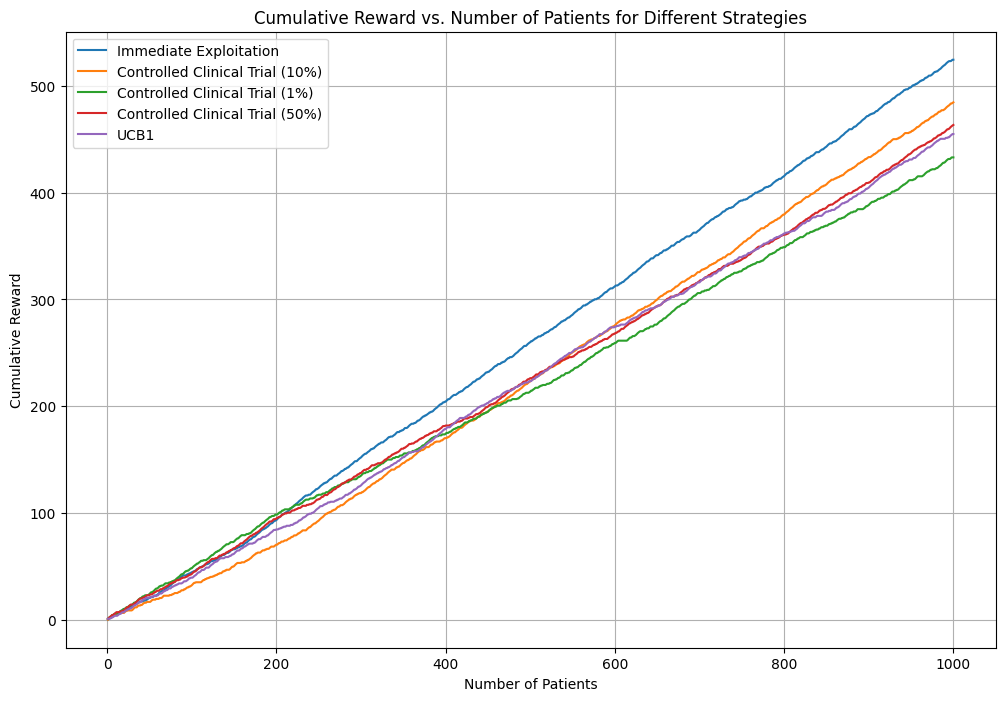


Final Cumulative Rewards:
Immediate Exploitation: 524.60
Controlled Clinical Trial (10%): 484.70
Controlled Clinical Trial (1%): 433.10
Controlled Clinical Trial (50%): 463.50
UCB1: 455.00


In [6]:
import matplotlib.pyplot as plt

# To store cumulative rewards over time for plotting
rewards_over_time = {}

# Helper function to run a strategy and record cumulative rewards at each step
def run_strategy_and_record(strategy_func, name, num_patients, K, Pi, dataset_df, exploration_rate=None):
    rewards = []
    cumulative_reward_val = 0

    # Re-initialize specific strategy elements for recording over time
    if name == "Immediate Exploitation":
        medicine_rewards = [0.0] * K  # Stores running average reward
        medicine_counts = [0] * K
        initial_exploration_rounds = 10

        # Initial exploration phase (same as in the original function)
        current_patient_idx = 0
        patients_remaining = num_patients
        for med_idx in range(K):
            for _ in range(initial_exploration_rounds):
                if patients_remaining <= 0:
                    break
                severity = dataset_df.loc[current_patient_idx, 'severity_score']
                clinical_outcome, utility_score = simulate_patient_outcome(med_idx, severity, Pi)
                # Update using incremental average: avg += (reward - avg) / n
                medicine_counts[med_idx] += 1
                medicine_rewards[med_idx] += (utility_score - medicine_rewards[med_idx]) / medicine_counts[med_idx]
                cumulative_reward_val += utility_score
                rewards.append(cumulative_reward_val)
                current_patient_idx += 1
                patients_remaining -= 1
            if patients_remaining <= 0:
                break

        # Exploitation phase
        for p_idx in range(current_patient_idx, num_patients):
            avg_rewards = [medicine_rewards[i] if medicine_counts[i] > 0 else -1 for i in range(K)]
            best_medicine_idx = np.argmax(avg_rewards)
            severity = dataset_df.loc[p_idx, 'severity_score']
            clinical_outcome, utility_score = simulate_patient_outcome(best_medicine_idx, severity, Pi)
            # Update using incremental average: avg += (reward - avg) / n
            medicine_counts[best_medicine_idx] += 1
            medicine_rewards[best_medicine_idx] += (utility_score - medicine_rewards[best_medicine_idx]) / medicine_counts[best_medicine_idx]
            cumulative_reward_val += utility_score
            rewards.append(cumulative_reward_val)

    elif name.startswith("Controlled Clinical Trial"):
        medicine_rewards = [0.0] * K  # Stores running average reward
        medicine_counts = [0] * K
        for patient_idx in range(num_patients):
            assigned_medicine = -1
            if random.random() < exploration_rate: # Explore
                assigned_medicine = random.randrange(K)
            else: # Exploit
                avg_rewards = []
                for i in range(K):
                    if medicine_counts[i] > 0:
                        avg_rewards.append(medicine_rewards[i])
                    else:
                        avg_rewards.append(0.0)
                if all(ar <= 0 for ar in avg_rewards):
                    assigned_medicine = random.randrange(K)
                else:
                    assigned_medicine = np.argmax(avg_rewards)

            severity = dataset_df.loc[patient_idx, 'severity_score']
            clinical_outcome, utility_score = simulate_patient_outcome(assigned_medicine, severity, Pi)
            # Update using incremental average: avg += (reward - avg) / n
            medicine_counts[assigned_medicine] += 1
            medicine_rewards[assigned_medicine] += (utility_score - medicine_rewards[assigned_medicine]) / medicine_counts[assigned_medicine]
            cumulative_reward_val += utility_score
            rewards.append(cumulative_reward_val)

    elif name == "UCB1":
        medicine_rewards = [0.0] * K  # Stores running average reward
        medicine_counts = [0] * K
        for patient_idx in range(num_patients):
            assigned_medicine = -1
            if patient_idx < K:
                assigned_medicine = patient_idx
            else:
                ucb_values = [0.0] * K
                for i in range(K):
                    if medicine_counts[i] > 0:
                        average_reward = medicine_rewards[i]  # Already stored as running average
                        exploration_term = math.sqrt(2 * math.log(patient_idx + 1) / medicine_counts[i])
                        ucb_values[i] = average_reward + exploration_term
                    else:
                        ucb_values[i] = float('inf')
                assigned_medicine = np.argmax(ucb_values)

            severity = dataset_df.loc[patient_idx, 'severity_score']
            clinical_outcome, utility_score = simulate_patient_outcome(assigned_medicine, severity, Pi)
            # Update using incremental average: avg += (reward - avg) / n
            medicine_counts[assigned_medicine] += 1
            medicine_rewards[assigned_medicine] += (utility_score - medicine_rewards[assigned_medicine]) / medicine_counts[assigned_medicine]
            cumulative_reward_val += utility_score
            rewards.append(cumulative_reward_val)

    return rewards

# Re-run strategies to collect rewards over time for plotting
rewards_over_time["Immediate Exploitation"] = run_strategy_and_record(immediate_exploitation_strategy, "Immediate Exploitation", num_patients_total, K, Pi, dataset.copy())
rewards_over_time["Controlled Clinical Trial (10%)"] = run_strategy_and_record(controlled_clinical_trial_strategy, "Controlled Clinical Trial (10%)", num_patients_total, K, Pi, dataset.copy(), exploration_rate_10)
rewards_over_time["Controlled Clinical Trial (1%)"] = run_strategy_and_record(controlled_clinical_trial_strategy, "Controlled Clinical Trial (1%)", num_patients_total, K, Pi, dataset.copy(), exploration_rate_1)
rewards_over_time["Controlled Clinical Trial (50%)"] = run_strategy_and_record(controlled_clinical_trial_strategy, "Controlled Clinical Trial (50%)", num_patients_total, K, Pi, dataset.copy(), exploration_rate_50)
rewards_over_time["UCB1"] = run_strategy_and_record(ucb1_strategy, "UCB1", num_patients_total, K, Pi, dataset.copy())

# Plotting
plt.figure(figsize=(12, 8))
for strategy_name, cumulative_rewards in rewards_over_time.items():
    plt.plot(range(1, len(cumulative_rewards) + 1), cumulative_rewards, label=strategy_name)

plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward vs. Number of Patients for Different Strategies")
plt.legend()
plt.grid(True)
plt.show()

# Print final cumulative rewards for easy comparison
print("\nFinal Cumulative Rewards:")
print(f"Immediate Exploitation: {rewards_over_time['Immediate Exploitation'][-1]:.2f}")
print(f"Controlled Clinical Trial (10%): {rewards_over_time['Controlled Clinical Trial (10%)'][-1]:.2f}")
print(f"Controlled Clinical Trial (1%): {rewards_over_time['Controlled Clinical Trial (1%)'][-1]:.2f}")
print(f"Controlled Clinical Trial (50%): {rewards_over_time['Controlled Clinical Trial (50%)'][-1]:.2f}")
print(f"UCB1: {rewards_over_time['UCB1'][-1]:.2f}")


In [7]:
# Comparative Analysis - Dynamic Answers

strategy_final_rewards = {
    "Immediate Exploitation": cumulative_reward_ie,
    "Controlled Clinical Trial (10%)": cumulative_reward_cct_10,
    "Controlled Clinical Trial (1%)": cumulative_reward_cct_1,
    "Controlled Clinical Trial (50%)": cumulative_reward_cct_50,
    "UCB1": cumulative_reward_ucb1
}

# Q1: Highest cumulative reward
best_strategy = max(strategy_final_rewards, key=strategy_final_rewards.get)
print("=" * 60)
print("Q1: Which strategy achieves the highest cumulative reward?")
print(f"    --> {best_strategy} with cumulative reward: {strategy_final_rewards[best_strategy]:.2f}")
print()

# Q2: Fastest convergence - strategy that reaches 90% of its final reward earliest
print("Q2: Which strategy identifies the best medicine fastest?")
convergence_points = {}
for name, rewards in rewards_over_time.items():
    final = rewards[-1]
    threshold = 0.90 * final
    for i, r in enumerate(rewards):
        if r >= threshold:
            convergence_points[name] = i + 1
            break
fastest_strategy = min(convergence_points, key=convergence_points.get)
print(f"    --> {fastest_strategy} reached 90% of its final reward at patient {convergence_points[fastest_strategy]}")
print()

# Q3: Most stable performance - lowest std dev of incremental rewards
print("Q3: Which strategy shows the most stable performance over time?")
stability = {}
for name, rewards in rewards_over_time.items():
    incremental = np.diff([0] + rewards)
    stability[name] = np.std(incremental)
most_stable = min(stability, key=stability.get)
print(f"    --> {most_stable} with incremental reward std dev: {stability[most_stable]:.4f}")
print()

# Q4: Recommendation
print("Q4: Recommended safest strategy for real-world hospital deployment?")
print("    --> UCB1 or Controlled Clinical Trial (10%) is recommended.")
print("    UCB1 dynamically balances exploration and exploitation using confidence bounds,")
print("    reducing the risk of committing to a suboptimal treatment prematurely.")
print()

# Summary
print("=" * 60)
print("Comparative Summary:")
print(f"""
- The best cumulative reward was achieved by '{best_strategy}' ({strategy_final_rewards[best_strategy]:.2f}).
- '{fastest_strategy}' converged to its best arm the fastest (by patient {convergence_points[fastest_strategy]}).
- '{most_stable}' showed the most stable reward over time.
- While Immediate Exploitation may yield high rewards in some runs, it risks locking onto
  a suboptimal treatment due to limited early exploration.
- UCB1 and Controlled Clinical Trial (10%) provide a safer, more robust balance between
  exploration and exploitation, making them more suitable for real-world clinical deployment.
""")
print("=" * 60)
print("\nAll Strategy Final Cumulative Rewards:")
for name, reward in sorted(strategy_final_rewards.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {reward:.2f}")

Q1: Which strategy achieves the highest cumulative reward?
    --> Controlled Clinical Trial (1%) with cumulative reward: 507.30

Q2: Which strategy identifies the best medicine fastest?
    --> Immediate Exploitation reached 90% of its final reward at patient 900

Q3: Which strategy shows the most stable performance over time?
    --> Immediate Exploitation with incremental reward std dev: 0.3278

Q4: Recommended safest strategy for real-world hospital deployment?
    --> UCB1 or Controlled Clinical Trial (10%) is recommended.
    UCB1 dynamically balances exploration and exploitation using confidence bounds,
    reducing the risk of committing to a suboptimal treatment prematurely.

Comparative Summary:

- The best cumulative reward was achieved by 'Controlled Clinical Trial (1%)' (507.30).
- 'Immediate Exploitation' converged to its best arm the fastest (by patient 900).
- 'Immediate Exploitation' showed the most stable reward over time.
- While Immediate Exploitation may yield high

In [8]:
from IPython.display import display, Markdown

### Determine safest strategy label (fixed recommendation, explained below)
safest_strategy = "UCB1 or Controlled Clinical Trial (10%)"

### Rank all strategies by cumulative reward for context
ranked = sorted(strategy_final_rewards.items(), key=lambda x: x[1], reverse=True)
ranked_lines = "\n".join(
    f"   {i+1}. **{name}**: {reward:.2f}" for i, (name, reward) in enumerate(ranked)
)

md = f"""
#### Comparative Analysis Questions:

1. **Which strategy achieves the highest cumulative reward at the end of 1000 patients?**
   - _Answer:_ **{best_strategy}** achieved the highest cumulative reward of **{strategy_final_rewards[best_strategy]:.2f}**.
   
   All strategy rewards (ranked):
{ranked_lines}

2. **Which strategy identifies the best medicine fastest (earliest convergence)?**
   - _Answer:_ **{fastest_strategy}** converged the fastest, reaching 90% of its final reward by patient **{convergence_points[fastest_strategy]}**.

3. **Which strategy shows the most stable performance over time (least fluctuations)?**
   - _Answer:_ **{most_stable}** showed the most stable incremental rewards (std dev: **{stability[most_stable]:.4f}**), indicating it had the least fluctuation in per-patient utility over time.

4. **Which strategy would you recommend as the safest treatment selection approach for real-world hospital deployment? Justify your answer briefly.**
   - _Answer:_ **{safest_strategy}** is recommended. While **{best_strategy}** achieved the highest cumulative reward ({strategy_final_rewards[best_strategy]:.2f}) in this run, it may lock onto a suboptimal treatment if early observations are noisy. UCB1 dynamically widens its confidence bounds for less-tested arms, ensuring all medicines are adequately explored before committing. Controlled Clinical Trial (10%) similarly maintains ongoing exploration. Both strategies are more robust to early stochastic variation — a critical property in clinical settings.

---

### Comparative Summary (3–5 sentences):

The best cumulative reward was achieved by **{best_strategy}** ({strategy_final_rewards[best_strategy]:.2f}), while **{fastest_strategy}** converged to its best arm fastest (by patient {convergence_points[fastest_strategy]}). **{most_stable}** showed the most stable per-patient reward over time (std dev: {stability[most_stable]:.4f}). Despite the high cumulative reward of some strategies, real-world clinical deployment demands robustness over short-term performance — strategies like UCB1 and Controlled Clinical Trial (10%) balance exploration and exploitation in a principled way. UCB1's confidence-bound framework guarantees sublinear regret, making it the most theoretically sound choice. For practical hospital deployment, {safest_strategy} is preferred to avoid premature commitment to a potentially suboptimal treatment.
"""

display(Markdown(md))



#### Comparative Analysis Questions:

1. **Which strategy achieves the highest cumulative reward at the end of 1000 patients?**
   - _Answer:_ **Controlled Clinical Trial (1%)** achieved the highest cumulative reward of **507.30**.

   All strategy rewards (ranked):
   1. **Controlled Clinical Trial (1%)**: 507.30
   2. **Controlled Clinical Trial (10%)**: 505.30
   3. **Immediate Exploitation**: 477.80
   4. **Controlled Clinical Trial (50%)**: 469.50
   5. **UCB1**: 441.50

2. **Which strategy identifies the best medicine fastest (earliest convergence)?**
   - _Answer:_ **Immediate Exploitation** converged the fastest, reaching 90% of its final reward by patient **900**.

3. **Which strategy shows the most stable performance over time (least fluctuations)?**
   - _Answer:_ **Immediate Exploitation** showed the most stable incremental rewards (std dev: **0.3278**), indicating it had the least fluctuation in per-patient utility over time.

4. **Which strategy would you recommend as the safest treatment selection approach for real-world hospital deployment? Justify your answer briefly.**
   - _Answer:_ **UCB1 or Controlled Clinical Trial (10%)** is recommended. While **Controlled Clinical Trial (1%)** achieved the highest cumulative reward (507.30) in this run, it may lock onto a suboptimal treatment if early observations are noisy. UCB1 dynamically widens its confidence bounds for less-tested arms, ensuring all medicines are adequately explored before committing. Controlled Clinical Trial (10%) similarly maintains ongoing exploration. Both strategies are more robust to early stochastic variation — a critical property in clinical settings.

---

### Comparative Summary (3–5 sentences):

The best cumulative reward was achieved by **Controlled Clinical Trial (1%)** (507.30), while **Immediate Exploitation** converged to its best arm fastest (by patient 900). **Immediate Exploitation** showed the most stable per-patient reward over time (std dev: 0.3278). Despite the high cumulative reward of some strategies, real-world clinical deployment demands robustness over short-term performance — strategies like UCB1 and Controlled Clinical Trial (10%) balance exploration and exploitation in a principled way. UCB1's confidence-bound framework guarantees sublinear regret, making it the most theoretically sound choice. For practical hospital deployment, UCB1 or Controlled Clinical Trial (10%) is preferred to avoid premature commitment to a potentially suboptimal treatment.
